# Summary: Adaptive Mixtures of Local Experts
**Authors:** Robert A. Jacobs, Michael I. Jordan, Steven J. Nowlan, Geoffrey E. Hinton

# https://www.cs.toronto.edu/~fritz/absps/jjnh91.pdf

## Abstract
This paper introduces a supervised learning procedure for systems composed of multiple separate "expert" networks, each specializing in a subset of training cases, coordinated by a gating network that determines which expert(s) handle each case. The approach unifies modular multilayer supervised learning with competitive learning under a single framework. By redefining the error function to encourage competition rather than cooperation among experts, the system learns to automatically decompose a task into subtasks, each solvable by a simple, local expert. The method is demonstrated on a speaker-independent, four-class vowel discrimination task, where it converges roughly twice as fast as standard backpropagation networks while achieving equivalent generalization performance.

## Problems
- Training a single, monolithic multilayer network via backpropagation to perform different subtasks on different training cases produces strong **interference effects** between subtasks, leading to slow learning and poor generalization.
- Prior modular systems addressing this (Hampshire and Waibel, 1989; Jacobs et al., 1990) use a linear-combination error function $$E^c = \|\mathbf{d}^c - \sum_i p_i^c \mathbf{o}_i^c\|^2$$ that does not encourage genuine localization: because each expert's output must cancel the *residual* error left by all other experts, the experts remain strongly coupled — a weight change in one expert alters the error derivatives for all others — which tends to produce solutions in which many experts contribute cooperatively to each case rather than one expert specializing per case.
- It is unclear, in general, how to make competitive learning (traditionally viewed as an unsupervised technique operating on "output-like" data vectors) function as an associative, input-conditional mechanism analogous to supervised learning.

## Proposed Solutions
- **Stochastic expert selection error function**: Rather than linearly blending expert outputs, the gating network makes a stochastic one-out-of-$n$ selection of a single expert per case, and the error is defined as the expected squared error over this selection: $$E^c = \langle \|\mathbf{d}^c - \mathbf{o}_i^c\|^2 \rangle = \sum_i p_i^c \|\mathbf{d}^c - \mathbf{o}_i^c\|^2$$ This decouples each expert's learning objective from the specific outputs of other experts (each must approximate the *whole* desired output, not a residual), reducing indirect coupling to changes in responsibility (gating) only, which cannot alter the *sign* of an expert's own error.
- **Negative log-probability (Gaussian mixture) error function**: An improved objective, motivated by a probabilistic (Gaussian mixture) interpretation, is used in practice: $$E^c = -\log \sum_i p_i^c e^{-\frac{1}{2}\|\mathbf{d}^c - \mathbf{o}_i^c\|^2}$$ This yields a derivative $$\frac{\partial E^c}{\partial \mathbf{o}_i^c} = -\left[\frac{p_i^c e^{-\frac{1}{2}\|\mathbf{d}^c-\mathbf{o}_i^c\|^2}}{\sum_j p_j^c e^{-\frac{1}{2}\|\mathbf{d}^c-\mathbf{o}_j^c\|^2}}\right](\mathbf{d}^c - \mathbf{o}_i^c)$$ that weights each expert's error signal by its *relative* fit compared to other experts (rather than only by its fixed gating proportion $p_i^c$), producing faster adaptation of the best-fitting expert early in training.
- **Gating network with softmax normalization**: The gating network outputs $$p_j = \frac{\exp(x_j)}{\sum_i \exp(x_i)}$$ where $x_j$ is the total weighted input to gating output unit $j$, ensuring outputs sum to 1 and can be interpreted as mixing proportions/responsibilities.
- **Associative generalization of competitive learning**: The framework reinterprets a competitive network's hidden units as generating output vectors (rather than processing input vectors) whose distribution matches a "data" distribution; replacing each hidden unit with an entire expert network (whose output specifies the mean of a multidimensional Gaussian, conditioned on the input) and adding a gating network to make mixing proportions input-dependent, yields a system of competing experts governed by the same probabilistic error function.

## Purpose
The central aim is to design a learning architecture and objective function that automatically and cleanly partitions a training set into subtasks handled by simple, local experts — reducing cross-task interference relative to monolithic backpropagation networks — while establishing a formal theoretical bridge between modular supervised learning and (associative) competitive learning.

## Methodology
- **Architecture**: A system of $n$ expert feedforward networks, each receiving the same input and producing outputs of the same dimensionality, plus a feedforward gating network (typically receiving the same input) whose softmax outputs $p_j$ parameterize a stochastic one-out-of-$n$ selector determining which expert's output is used on a given trial (Figure 1).
- **Task and Data**: Speaker-independent, four-class vowel discrimination (vowels [i], [I], [a], [Λ]) using first and second formant values from 75 speakers (males, females, children) in an hVd context (Peterson and Barney, 1952). Data form two overlapping class pairs: {[i],[I]} and {[a],[Λ]}. Training used the first 50 speakers; testing used the remaining 25.
- **Comparative models**: Standard backpropagation networks with a single hidden layer of 6 or 12 units were compared against mixtures of 4 or 8 experts. Each expert was deliberately restricted to a simple architecture capable of forming only a **linear decision surface** (defined by the set of inputs producing an output of exactly 0.5). Hidden-unit/expert counts were chosen to give roughly equal parameter counts across the compared systems.
- **Training procedure**: All models used simple fixed-step-size ($\epsilon$) gradient descent with **batch training** (one weight update per epoch) and **no momentum or other acceleration techniques**, to simplify comparison. Step sizes were selected via limited exploration of convergence from identical initial conditions. Training continued until an average squared error of 0.08 over the training set was reached; 25 simulations were run per system.
- **Evaluation metrics**: Percent correct classification on training and test sets (based on the most probable class under the gating-weighted mixture of each expert's probability distribution over classes), average number of epochs to reach the error criterion, and standard deviation of convergence times. Statistical comparisons used a $t$-test with 48 degrees of freedom and a pooled variance estimator.

## Results
- All four systems (4 experts, 8 experts, backpropagation with 6 hidden units, backpropagation with 12 hidden units) achieved **identical classification performance**: 88% correct on training data and 90% correct on test data (Table 1) — attributed to the misclassified-example set being insensitive to small decision-surface changes in this dataset, and to the test set being intrinsically easier than the training set.
- **Convergence speed** differed substantially: mixtures of experts reached the error criterion significantly faster than backpropagation networks ($p \gg 0.999$), requiring roughly **half as many epochs on average** (4 experts: 1124 epochs; 8 experts: 1083 epochs; vs. 6-hidden-unit BP: 2209 epochs; 12-hidden-unit BP: 2435 epochs).
- The mixture model's learning time **scaled favorably** with the number of experts: 8 experts showed a small but statistically significant ($p > 0.95$) speed advantage over 4 experts, whereas the 12-hidden-unit backpropagation network required *more* epochs ($p > 0.95$) than the 6-hidden-unit network — indicating opposite scaling behavior between the two paradigms as capacity increases.
- **Task decomposition dynamics** (Figure 2, Figure 3): Although the mixture models contained 4 or 8 experts, only 2–3 experts typically had non-negligible mixing proportions in the final solution; the rest had proportions effectively 0 for all cases. Early in training, with the gating network assigning near-equal responsibility to all experts, every expert's decision line converges toward a shared "average" solution (point X) handling all four classes jointly. As symmetry breaks (once some experts start receiving disproportionate error from a specific class pair), expert decision lines diverge and specialize — e.g., one expert approaching the optimal single-line discriminant for {[i],[I]}, while two others jointly approach and then split from the optimal line for {[a],[Λ]}, forming a piecewise-linear approximation to the slightly curved true boundary between [a] and [Λ].
- The gating network's own decision boundary (e.g., "Gate 0:2") combines with individual experts' linear boundaries to produce a composite, appropriately curved decision surface for the overall task.

## Conclusions
The paper demonstrates that redefining the error function to foster genuine competition among local experts — rather than cooperative residual-correction under a linear-combination objective — enables a mixture-of-experts system to automatically and effectively decompose a task into coherent subtasks, each solved by a very simple (linear) expert. Empirically, on the vowel discrimination benchmark, this architecture matches standard backpropagation's generalization accuracy while converging roughly twice as fast, with more favorable scaling as more experts are added. The work formally connects modular supervised learning and competitive learning by reframing competitive learning as a generative, input-conditional process (a Gaussian mixture model with input-dependent means and mixing proportions), providing a principled probabilistic foundation (negative log-likelihood error) for expert competition. The authors note that decomposition is not merely capacity-limited: the observed near-piecewise-linear decomposition reflects genuine sensitivity to problem structure (e.g., the curved [a]/[Λ] boundary), rather than an arbitrary partition. This work established a foundational architecture — the mixture-of-experts (gating + local experts) framework — later widely extended in probabilistic and hierarchical mixture-of-experts models.

# Mathematical and Statistical Content Summary
**Paper:** Adaptive Mixtures of Local Experts (Jacobs, Jordan, Nowlan, Hinton)

## 1. Linear-Combination Error Function (Baseline / Prior Approach)

$$E^c = \left\|\mathbf{d}^c - \sum_i p_i^c \mathbf{o}_i^c\right\|^2$$

**Meaning:** The system's output is a weighted blend of all experts' outputs $\mathbf{o}_i^c$, mixed according to gating proportions $p_i^c$. Error is the squared distance between this blend and the desired output $\mathbf{d}^c$. This is the error function used by earlier systems (Hampshire and Waibel; Jacobs et al. 1990). It is presented as flawed: because the *combination* is compared to the target, each expert only needs to correct the *residual* left by the others, so all experts remain coupled and tend to cooperate rather than specialize.

## 2. Stochastic Selection Error Function (Proposed Improvement)

$$E^c = \left\langle \|\mathbf{d}^c - \mathbf{o}_i^c\|^2 \right\rangle = \sum_i p_i^c \|\mathbf{d}^c - \mathbf{o}_i^c\|^2$$

**Meaning:** Instead of blending outputs, the gating network stochastically picks a *single* expert (a "one-out-of-$n$" selector) with probability $p_i^c$. The error is the *expected value* of squared error under this stochastic choice. Now each expert is scored against the full target directly, not a residual — decoupling experts' objectives from each other's specific outputs. This is a statistical expectation (weighted average over a categorical/discrete random variable — which expert is chosen).

## 3. Derivative of the Stochastic Selection Error

$$\frac{\partial E^c}{\partial \mathbf{o}_i^c} = -2p_i^c(\mathbf{d}^c - \mathbf{o}_i^c)$$

**Meaning:** The gradient used to update expert $i$'s output is proportional to its own error, scaled only by its fixed gating weight $p_i^c$. This is the quantity backpropagated into each expert network to drive learning. Its limitation: early in training, when all $p_i^c$ are roughly equal, the *best-fitting* expert is adapted no faster than any other — slowing specialization.

## 4. Softmax Function (Gating Network Output)

$$p_j = \frac{\exp(x_j)}{\sum_i \exp(x_i)}$$

**Meaning:** The gating network's raw outputs $x_j$ (weighted sums of inputs) are converted into a valid probability distribution — all $p_j \geq 0$ and $\sum_j p_j = 1$. This is the now-standard **softmax function**, used here to interpret gating outputs as "responsibility" or mixing proportions across experts. It converts arbitrary real-valued scores into normalized probabilities.

## 5. Negative Log-Probability Error Function (Final, Best-Performing Objective)

$$E^c = -\log \sum_i p_i^c \, e^{-\frac{1}{2}\|\mathbf{d}^c - \mathbf{o}_i^c\|^2}$$

**Meaning:** This is the **negative log-likelihood** of the target vector under a Gaussian mixture model, where each expert defines the mean of one Gaussian component with fixed (unit) variance, and $p_i^c$ is that component's mixing weight. This reframes the whole learning problem statistically: minimizing $E^c$ is equivalent to maximum likelihood estimation of a mixture-of-Gaussians model whose parameters (means) are themselves computed by neural networks conditioned on the input. This is the key conceptual bridge between neural network training and probabilistic mixture modeling.

## 6. Derivative of the Log-Probability Error Function

$$\frac{\partial E^c}{\partial \mathbf{o}_i^c} = -\left[\frac{p_i^c\, e^{-\frac{1}{2}\|\mathbf{d}^c-\mathbf{o}_i^c\|^2}}{\sum_j p_j^c\, e^{-\frac{1}{2}\|\mathbf{d}^c-\mathbf{o}_j^c\|^2}}\right](\mathbf{d}^c - \mathbf{o}_i^c)$$

**Meaning:** This is a **posterior responsibility** — by Bayes' rule, the bracketed term is exactly the posterior probability that expert $i$ "generated" the observed target $\mathbf{d}^c$, given all experts' current fits (this is the E-step-like quantity familiar from the EM algorithm for mixture models). Unlike the earlier derivative (which used only the fixed prior $p_i^c$), this reweights each expert's error signal by how *relatively well* it currently fits the data compared to other experts — so a well-fitting expert gets a much larger learning signal than a poorly-fitting one, even if their prior gating weights are similar. This produces faster specialization.

## 7. Log-Probability of Generating an Output Vector (Gaussian Mixture Model)

$$\log P^c = \log \sum_i p_i \, k\, e^{-\frac{1}{2}\|\boldsymbol{\mu}_i - \mathbf{o}^c\|^2}$$

**Meaning:** This generalizes the competitive-learning perspective: each hidden/expert unit $i$ has a "weight" vector $\boldsymbol{\mu}_i$ representing the mean of a Gaussian, $k$ is a normalizing constant, and $p_i$ are the **mixing proportions** (statistical term from mixture modeling, citing McLachlan and Basford 1988) with $\sum_i p_i = 1$. Generating an output vector is modeled as a two-step stochastic process: (1) pick a component/hidden unit $i$ with probability $p_i$, then (2) sample from that component's Gaussian distribution. This equation is the total log-likelihood of an observed vector under this generative mixture process — the foundation that the paper's neural mixture-of-experts objective (Eq. 1.3) directly extends by making $\boldsymbol{\mu}_i$ and $p_i$ functions of an input vector rather than fixed weights.

## 8. Soft vs. Hard Competitive Learning (Statistical Estimation Distinction)

**Meaning:**
- **Soft competitive learning**: adjusts *all* component means, variances, and mixing proportions to increase the overall **likelihood** of the training data (a proper maximum-likelihood mixture-fitting procedure).
- **Hard competitive learning**: an approximation that assumes each data point could only have been generated by the single nearest component (ignoring the possibility that it could plausibly come from multiple components), so only the closest unit's mean is updated.

This distinction sets up the paper's own hybrid approach — a "soft" stochastic-but-differentiable assignment scheme (via $p_i^c$) that lies between the two extremes, generalized to be input-conditional.

## 9. Statistical Significance Testing (Experimental Comparison)

**Method:** Independent-samples **$t$-test** with pooled variance estimator, 48 degrees of freedom (from 25 simulations per system, two systems compared: $25+25-2=48$).

**Meaning:** Used to test whether differences in average number of epochs to convergence between systems (e.g., mixture-of-experts vs. backpropagation networks) are statistically significant. Reported results:
- Mixtures of experts converge faster than backpropagation networks ($p \gg 0.999$) — a highly significant difference.
- 8 experts converge modestly faster than 4 experts ($p > 0.95$) — a significant but smaller effect.
- A 12-hidden-unit backpropagation network converges *slower* than a 6-hidden-unit network ($p > 0.95$) — significant in the opposite direction, illustrating a scaling difference between the two model classes.

This is a classical frequentist hypothesis-testing approach applied to compare convergence-speed distributions across model architectures.

## 10. Descriptive Statistics of Convergence (Table 1)

**Metrics used:** Percent correct classification (train/test), average number of epochs to reach a fixed error criterion (0.08 average squared error over the training set), and the standard deviation (SD) of the convergence-time distribution across 25 simulations.

**Meaning:** These are basic descriptive statistics (mean and standard deviation) summarizing the empirical distribution of training outcomes across repeated random initializations, used as the raw data underlying the $t$-tests above.

## Summary Table

| Concept | Type | Role in Paper |
|---|---|---|
| Linear-combination error $E^c = \|\mathbf{d}^c - \sum_i p_i^c \mathbf{o}_i^c\|^2$ | Loss function (baseline) | Shows why prior mixture systems fail to localize/specialize experts |
| Stochastic selection error $E^c = \sum_i p_i^c \|\mathbf{d}^c-\mathbf{o}_i^c\|^2$ | Loss function (expectation) | Decouples experts by requiring each to match the full target |
| Derivative of stochastic error | Gradient / calculus | Shows why early-training adaptation is slow under this simpler objective |
| Softmax $p_j = \exp(x_j)/\sum_i \exp(x_i)$ | Normalization function | Converts gating network outputs into valid mixing probabilities |
| Negative log-probability error (Eq. 1.3) | Loss function (statistical) | Final, best-performing objective; equivalent to Gaussian mixture likelihood |
| Derivative of log-probability error | Gradient / Bayesian posterior | Produces faster, relevance-weighted learning per expert |
| Log-probability of a Gaussian mixture (Eq. 2.1) | Generative probabilistic model | Formal bridge connecting competitive learning to mixture-of-experts |
| Soft vs. hard competitive learning | Statistical estimation methods | Contextualizes the paper's method between full ML estimation and nearest-neighbor approximation |
| Independent $t$-test (48 df, pooled variance) | Statistical significance test | Validates that mixture-of-experts converges faster than backpropagation |
| Mean and standard deviation of convergence epochs | Descriptive statistics | Empirical basis for comparing convergence speed and variability across systems |

# Problems, Limitations, and Proposed Solutions

| # | Problem / Research Gap | Limitation of Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Training a single monolithic multilayer network via backpropagation to handle different subtasks on different training cases produces strong **interference effects** between subtasks. | Leads to slow learning and poor generalization, since weight updates for one subtask can disrupt weights relevant to another, unrelated subtask. | Propose a modular system of separate "expert" networks plus a gating network, so that weight changes for a given case are localized to the responsible expert(s), reducing cross-task interference. |
| 2 | Existing modular systems that learn the task decomposition (Jacobs et al. 1990) and hand-specified decomposition systems (Hampshire and Waibel, 1989) both use a **linear-combination error function** $$E^c = \|\mathbf{d}^c - \sum_i p_i^c \mathbf{o}_i^c\|^2$$ | This error function does not encourage true localization: since the combined blend of expert outputs is compared to the target, each expert must correct the residual error left by all others, causing strong coupling between experts' weight updates and encouraging *cooperative* solutions where many experts contribute to each case rather than one specializing. | Redefine the error function using a **stochastic one-out-of-$n$ expert selection** scheme, in which the gating network probabilistically selects a single expert per case and the error is the expectation of squared error under that choice: $$E^c = \sum_i p_i^c \|\mathbf{d}^c - \mathbf{o}_i^c\|^2$$ This requires each expert to approximate the whole target directly, largely decoupling experts' learning objectives from one another. |
| 3 | Even under the stochastic selection error function, the gradient with respect to an expert's output, $$\frac{\partial E^c}{\partial \mathbf{o}_i^c} = -2p_i^c(\mathbf{d}^c-\mathbf{o}_i^c)$$ weights each expert's learning signal only by its (initially near-uniform) gating proportion $p_i^c$. | Early in training, when the gating network assigns roughly equal responsibility to all experts, this measure adapts the best-fitting expert the *slowest*, since it does not distinguish how well an expert is doing relative to the others — slowing the emergence of specialization. | Adopt a **negative log-probability (Gaussian mixture) error function** $$E^c = -\log \sum_i p_i^c e^{-\frac{1}{2}\|\mathbf{d}^c-\mathbf{o}_i^c\|^2}$$ whose derivative reweights each expert's error by a posterior-like term reflecting its *relative* fit to the target compared to other experts, adapting the best-fitting expert fastest. |
| 4 | It is not obvious, in general, what role input vectors play in a purely competitive (unsupervised) learning network, since data vectors in competitive learning are conventionally treated analogously to inputs of an associative network rather than outputs. | Standard competitive learning has no natural mechanism for making cluster assignments (mixing proportions) or cluster means conditional on an input vector, limiting its applicability to associative/supervised-style problems. | Reinterpret competitive learning as an **inputless stochastic generator of output vectors** governed by a Gaussian mixture model, then generalize each "hidden unit" into a full expert network whose output specifies an input-conditional Gaussian mean, with a gating network making the mixing proportions input-dependent — yielding a unified probabilistic framework connecting competitive and associative (supervised) learning. |
| 5 | No established architecture existed at the time that combined competitive-style task allocation with gradient-based supervised learning while simultaneously supporting fast convergence and strong generalization on real-world classification tasks. | Standard single-network backpropagation approaches required more training epochs to converge and offered no explicit mechanism for interpretable task decomposition. | Empirically validate the proposed mixture-of-experts framework on a speaker-independent, four-class vowel discrimination task, demonstrating both convergence roughly twice as fast as backpropagation networks with comparable parameter counts and equivalent generalization accuracy, alongside interpretable per-expert task decomposition (Figures 2–3). |

In [1]:
# !pip -q install datasets scikit-learn

# ============================================================
# Educational Replication:
# "Adaptive Mixtures of Local Experts"
# Jacobs, Jordan, Nowlan, Hinton (1991)
# Adapted to CIFAR-10 classification.
#
# CORE IDEA OF THE PAPER:
# Instead of forcing one large network to learn every part of a task
# (which causes interference between unrelated subtasks), we use several
# independent "expert" networks plus a "gating" network. The gate looks
# at the input and decides how much responsibility each expert should
# have for that input. The final prediction is a probability-weighted
# mixture of all experts' predictions. Training uses the negative
# log-likelihood of this mixture, which naturally produces a form of
# competition: experts that already explain a sample well get a
# stronger learning signal (via their posterior "responsibility"),
# encouraging different experts to specialize on different subsets of
# the data -- without ever hardcoding which expert handles which class.
# ============================================================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, Subset, DataLoader

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec

from sklearn.metrics import confusion_matrix, accuracy_score

from datasets import load_dataset

from io import BytesIO
from IPython.display import display, Image as IPImage

In [2]:
# ------------------------------------------------------------
# GLOBAL WHITE VISUAL THEME
# ------------------------------------------------------------
def apply_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "axes.titlecolor": "black",
        "text.color": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.labelcolor": "black",
        "grid.color": "#dddddd",
        "savefig.facecolor": "white",
    })

apply_white_theme()

In [3]:
# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPS = 1e-8  # numerical safety epsilon used throughout

In [4]:
# ------------------------------------------------------------
# CLASS NAMES
# ------------------------------------------------------------
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]
NUM_CLASSES = len(class_names)

In [ ]:
# ------------------------------------------------------------
# DATASET (HuggingFace CIFAR-10 only)
# ------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

class HFCifar10Dataset(Dataset):
    """Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset."""
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img = img.convert("RGB")
        img = self.transform(img)
        label = int(item["label"])
        return img, label

full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

In [6]:
# ------------------------------------------------------------
# SUBSETS AND DATA LOADERS
# ------------------------------------------------------------
N_TRAIN = 2000
N_TEST = 400

train_dataset = Subset(full_train_dataset, list(range(N_TRAIN)))
test_dataset = Subset(full_test_dataset, list(range(N_TEST)))

pin_mem = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True,
    num_workers=2, pin_memory=pin_mem
)
test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False,
    num_workers=2, pin_memory=pin_mem
)

In [7]:
# ------------------------------------------------------------
# ARCHITECTURE CONSTANTS
# ------------------------------------------------------------
NUM_EXPERTS = 4
POOL_SIZE = 16
INPUT_DIM = 3 * POOL_SIZE * POOL_SIZE  # 768
EXPERT_HIDDEN = 64
GATE_HIDDEN = 32

def pool_and_flatten(images):
    """Adaptive average pool to 16x16, then flatten. This shared,
    non-trainable operation keeps the input small enough for simple
    fully-connected experts and gate, while retaining coarse
    spatial/color structure."""
    pooled = F.adaptive_avg_pool2d(images, (POOL_SIZE, POOL_SIZE))
    flat = pooled.view(pooled.size(0), -1)
    return pooled, flat

In [8]:
# ------------------------------------------------------------
# EXPERT NETWORK
# ------------------------------------------------------------
class ExpertNetwork(nn.Module):
    """A small, independent feed-forward classifier. Each expert produces
    a COMPLETE prediction over all 10 classes -- it is not responsible
    for only a slice of the output, only (potentially) a slice of the
    input space, which the gate will discover through training."""
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=EXPERT_HIDDEN, num_classes=NUM_CLASSES):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        h = torch.tanh(self.fc1(x))
        logits = self.fc2(h)
        return logits

In [9]:
# ------------------------------------------------------------
# GATING NETWORK
# ------------------------------------------------------------
class GatingNetwork(nn.Module):
    """Looks at the same input as the experts and decides how much
    responsibility each expert should have. Its softmax output ensures
    gate probabilities are non-negative and sum to one per sample,
    exactly matching the paper's normalized gating scheme."""
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=GATE_HIDDEN, num_experts=NUM_EXPERTS):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_experts)

    def forward(self, x):
        h = torch.tanh(self.fc1(x))
        logits = self.fc2(h)
        return logits

In [10]:
# ------------------------------------------------------------
# MIXTURE OF EXPERTS MODEL
# ------------------------------------------------------------
class MixtureOfExperts(nn.Module):
    """
    Combines NUM_EXPERTS independent expert networks with one gating
    network. Experts do NOT share parameters -- each is a separate
    nn.Module instance, so their weight updates never interfere with
    one another directly (only indirectly, through the shared mixture
    loss and the gate's routing decisions).
    """
    def __init__(self):
        super().__init__()
        self.experts = nn.ModuleList([ExpertNetwork() for _ in range(NUM_EXPERTS)])
        self.gate = GatingNetwork()

    def forward(self, images):
        pooled, flat = pool_and_flatten(images)

        # Every expert independently produces a complete probability
        # distribution over all 10 classes. Logits must NOT be averaged
        # before softmax -- each expert's softmax is computed separately
        # so the mixture is a mixture of PROBABILITIES, not of logits.
        expert_logits_list = [expert(flat) for expert in self.experts]
        expert_logits = torch.stack(expert_logits_list, dim=1)  # [B, NUM_EXPERTS, 10]
        expert_probs = F.softmax(expert_logits, dim=-1)          # [B, NUM_EXPERTS, 10]

        gate_logits = self.gate(flat)                            # [B, NUM_EXPERTS]
        gate_probs = F.softmax(gate_logits, dim=-1)               # [B, NUM_EXPERTS]

        # Mixture probability = weighted sum of expert probabilities,
        # weighted by the gate's mixing probabilities.
        mixture_probs = torch.einsum("be,bec->bc", gate_probs, expert_probs)  # [B, 10]

        return {
            "pooled": pooled,
            "flat": flat,
            "expert_logits": expert_logits,
            "expert_probs": expert_probs,
            "gate_logits": gate_logits,
            "gate_probs": gate_probs,
            "mixture_probs": mixture_probs,
        }

model = MixtureOfExperts().to(device)

In [11]:
# ------------------------------------------------------------
# SANITY CHECK
# ------------------------------------------------------------
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

with torch.no_grad():
    sample_out = model(sample_images)

pooled_sample = sample_out["pooled"]
flat_sample = sample_out["flat"]
expert_probs_sample = sample_out["expert_probs"]
gate_probs_sample = sample_out["gate_probs"]
mixture_probs_sample = sample_out["mixture_probs"]

# Compute responsibilities for the sanity-check batch.
def compute_responsibilities(expert_probs, gate_probs, labels):
    """
    Responsibility_i = gate_i * P(true class | expert i)
                        --------------------------------
                        sum_j gate_j * P(true class | expert j)

    This is the POSTERIOR probability that expert i is "responsible"
    for correctly explaining this sample, given how well each expert
    currently predicts the true class and how much the gate currently
    trusts each expert. It differs from the gate's raw output because
    it also incorporates each expert's actual performance on this
    specific sample (a Bayesian update on the gate's prior belief).
    """
    batch_size = labels.size(0)
    idx = labels.view(-1, 1, 1).expand(-1, expert_probs.size(1), 1)
    expert_true_prob = torch.gather(expert_probs, dim=2, index=idx).squeeze(-1)  # [B, NUM_EXPERTS]
    weighted = gate_probs * expert_true_prob  # [B, NUM_EXPERTS]
    denom = weighted.sum(dim=1, keepdim=True) + EPS
    responsibilities = weighted / denom
    return responsibilities, expert_true_prob

resp_sample, expert_true_prob_sample = compute_responsibilities(
    expert_probs_sample, gate_probs_sample, sample_labels
)

print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))
print("Image-batch shape:", tuple(sample_images.shape))
print("Label-batch shape:", tuple(sample_labels.shape))
print("Min label:", int(sample_labels.min()), "| Max label:", int(sample_labels.max()))
print("First 8 labels:", sample_labels[:8].tolist())
print("First 8 class names:", [class_names[i] for i in sample_labels[:8].tolist()])
print("Pooled feature shape:", tuple(pooled_sample.shape))
print("Flattened feature shape:", tuple(flat_sample.shape))
print("Expert-probability tensor shape:", tuple(expert_probs_sample.shape))
print("Gate-probability tensor shape:", tuple(gate_probs_sample.shape))
print("Mixture-probability tensor shape:", tuple(mixture_probs_sample.shape))
print("Responsibility tensor shape:", tuple(resp_sample.shape))

assert sample_labels.min() >= 0 and sample_labels.max() <= 9, "Labels out of range."
assert torch.allclose(gate_probs_sample.sum(dim=1), torch.ones(gate_probs_sample.size(0), device=device), atol=1e-4), \
    "Gate probabilities must sum to one."
assert torch.allclose(expert_probs_sample.sum(dim=-1), torch.ones(expert_probs_sample.shape[:2], device=device), atol=1e-4), \
    "Every expert distribution must sum to one."
assert torch.allclose(mixture_probs_sample.sum(dim=1), torch.ones(mixture_probs_sample.size(0), device=device), atol=1e-4), \
    "Mixture class probabilities must sum to one."
assert torch.allclose(resp_sample.sum(dim=1), torch.ones(resp_sample.size(0), device=device), atol=1e-3), \
    "Responsibilities must sum to one."
assert torch.isfinite(mixture_probs_sample).all(), "Mixture probabilities must be finite."

Number of training samples: 2000
Number of test samples: 400
Image-batch shape: (64, 3, 64, 64)
Label-batch shape: (64,)
Min label: 0 | Max label: 9
First 8 labels: [6, 1, 9, 6, 8, 1, 3, 6]
First 8 class names: ['frog', 'automobile', 'truck', 'frog', 'ship', 'automobile', 'cat', 'frog']
Pooled feature shape: (64, 3, 16, 16)
Flattened feature shape: (64, 768)
Expert-probability tensor shape: (64, 4, 10)
Gate-probability tensor shape: (64, 4)
Mixture-probability tensor shape: (64, 10)
Responsibility tensor shape: (64, 4)


In [12]:
# ------------------------------------------------------------
# OPTIMIZATION SETUP
# ------------------------------------------------------------
EPOCHS = 5
LEARNING_RATE = 0.05

# Matching the paper's simple fixed-step gradient descent experiments:
# plain SGD, no momentum, no scheduler.
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.0)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

In [13]:
# ------------------------------------------------------------
# LOSS: MIXTURE NEGATIVE LOG-LIKELIHOOD
# ------------------------------------------------------------
def mixture_nll_loss(mixture_probs, labels):
    """
    -mean(log(mixture_probability_of_true_class + eps))

    This is the paper's core objective (Eq. 1.3 generalization): the
    negative log-likelihood of the correct class under the probabilistic
    mixture. We deliberately do NOT use CrossEntropyLoss on averaged
    logits, because that would implicitly average logits before
    softmax -- a different (and less faithful) computation.
    """
    true_class_probs = torch.gather(mixture_probs, 1, labels.view(-1, 1)).squeeze(1)
    nll = -torch.log(true_class_probs + EPS)
    return nll.mean(), true_class_probs

In [14]:
# ------------------------------------------------------------
# DIAGNOSTIC METRICS
# ------------------------------------------------------------
def gate_entropy_fn(gate_probs):
    return (-(gate_probs * torch.log(gate_probs + EPS)).sum(dim=1)).mean()

def responsibility_entropy_fn(responsibilities):
    return (-(responsibilities * torch.log(responsibilities + EPS)).sum(dim=1)).mean()

def expert_standalone_nll(expert_true_prob):
    # expert_true_prob: [B, NUM_EXPERTS]
    return (-torch.log(expert_true_prob + EPS)).mean(dim=0)  # [NUM_EXPERTS]

def responsibility_weighted_expert_loss(responsibilities, expert_true_prob):
    # Use detached responsibilities as a DIAGNOSTIC-only weighting.
    resp_detached = responsibilities.detach()
    weighted = -(resp_detached * torch.log(expert_true_prob + EPS))
    return weighted.mean(dim=0)  # [NUM_EXPERTS]

def expert_agreement_rate(expert_probs):
    # Fraction of samples where all experts agree on the predicted class.
    expert_preds = expert_probs.argmax(dim=-1)  # [B, NUM_EXPERTS]
    first_pred = expert_preds[:, 0:1]
    all_agree = (expert_preds == first_pred).all(dim=1)
    return all_agree.float().mean().item()

In [15]:
# ------------------------------------------------------------
# HISTORY TRACKING
# ------------------------------------------------------------
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "expert_standalone_nll": [],       # list of [NUM_EXPERTS] arrays per epoch
    "expert_weighted_loss": [],        # list of [NUM_EXPERTS] arrays per epoch
    "gate_prob_mean": [],              # list of [NUM_EXPERTS] arrays per epoch
    "responsibility_mean": [],         # list of [NUM_EXPERTS] arrays per epoch
    "gate_entropy": [], "responsibility_entropy": [],
    "expert_utilization_gate": [],     # % samples where expert has max gate prob
    "expert_utilization_resp": [],     # % samples where expert has max responsibility
    "expert_agreement_rate": [],
    "expert_standalone_acc": [],       # list of [NUM_EXPERTS] arrays per epoch
    "per_class_val_acc": [],           # list of length-10 arrays per epoch
    "per_class_gate_prob": [],         # list of [10, NUM_EXPERTS] arrays per epoch
    "per_class_responsibility": [],    # list of [10, NUM_EXPERTS] arrays per epoch
}

In [16]:
# ------------------------------------------------------------
# EVALUATION FUNCTION
# ------------------------------------------------------------
@torch.no_grad()
def evaluate(loader):
    all_labels, all_mix_preds, all_mix_probs = [], [], []
    all_expert_preds, all_expert_probs = [], []
    all_gate_probs, all_responsibilities = [], []
    total_loss, n_samples = 0.0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        out = model(images)
        mixture_probs = out["mixture_probs"]
        expert_probs = out["expert_probs"]
        gate_probs = out["gate_probs"]

        loss, _ = mixture_nll_loss(mixture_probs, labels)
        total_loss += loss.item() * images.size(0)
        n_samples += images.size(0)

        responsibilities, expert_true_prob = compute_responsibilities(expert_probs, gate_probs, labels)

        mix_preds = mixture_probs.argmax(dim=1)
        expert_preds = expert_probs.argmax(dim=-1)  # [B, NUM_EXPERTS]

        all_labels.append(labels.cpu())
        all_mix_preds.append(mix_preds.cpu())
        all_mix_probs.append(mixture_probs.cpu())
        all_expert_preds.append(expert_preds.cpu())
        all_expert_probs.append(expert_probs.cpu())
        all_gate_probs.append(gate_probs.cpu())
        all_responsibilities.append(responsibilities.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_mix_preds = torch.cat(all_mix_preds).numpy()
    all_mix_probs = torch.cat(all_mix_probs).numpy()
    all_expert_preds = torch.cat(all_expert_preds).numpy()
    all_expert_probs = torch.cat(all_expert_probs).numpy()
    all_gate_probs = torch.cat(all_gate_probs).numpy()
    all_responsibilities = torch.cat(all_responsibilities).numpy()

    acc = accuracy_score(all_labels, all_mix_preds)
    avg_loss = total_loss / n_samples

    per_class_acc = np.zeros(NUM_CLASSES)
    per_class_gate = np.zeros((NUM_CLASSES, NUM_EXPERTS))
    per_class_resp = np.zeros((NUM_CLASSES, NUM_EXPERTS))
    for c in range(NUM_CLASSES):
        mask = all_labels == c
        if mask.any():
            per_class_acc[c] = (all_mix_preds[mask] == c).mean()
            per_class_gate[c] = all_gate_probs[mask].mean(axis=0)
            per_class_resp[c] = all_responsibilities[mask].mean(axis=0)

    expert_standalone_acc = np.zeros(NUM_EXPERTS)
    for e in range(NUM_EXPERTS):
        expert_standalone_acc[e] = (all_expert_preds[:, e] == all_labels).mean()

    return {
        "loss": avg_loss, "acc": acc,
        "labels": all_labels, "mix_preds": all_mix_preds, "mix_probs": all_mix_probs,
        "expert_preds": all_expert_preds, "expert_probs": all_expert_probs,
        "gate_probs": all_gate_probs, "responsibilities": all_responsibilities,
        "per_class_acc": per_class_acc,
        "per_class_gate": per_class_gate,
        "per_class_resp": per_class_resp,
        "expert_standalone_acc": expert_standalone_acc,
    }

In [17]:
# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------
print("\nStarting training (Mixture of Local Experts)...\n")

specialization_evolution = []  # list of (epoch, per_class_resp matrix)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, running_correct, running_n = 0.0, 0, 0

    epoch_expert_nll_accum = []
    epoch_expert_weighted_accum = []
    epoch_gate_mean_accum = []
    epoch_resp_mean_accum = []
    epoch_gate_entropy_accum = []
    epoch_resp_entropy_accum = []
    epoch_agreement_accum = []
    epoch_gate_util_accum = []
    epoch_resp_util_accum = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        out = model(images)
        mixture_probs = out["mixture_probs"]
        expert_probs = out["expert_probs"]
        gate_probs = out["gate_probs"]

        # Explicit posterior responsibilities for this batch (used for
        # diagnostics/analysis; autograd differentiates the mixture NLL
        # directly, which implicitly encodes the same competitive signal).
        responsibilities, expert_true_prob = compute_responsibilities(expert_probs, gate_probs, labels)

        loss, true_class_probs = mixture_nll_loss(mixture_probs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = mixture_probs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_n += images.size(0)

        with torch.no_grad():
            standalone_nll = expert_standalone_nll(expert_true_prob)
            weighted_loss = responsibility_weighted_expert_loss(responsibilities, expert_true_prob)
            g_ent = gate_entropy_fn(gate_probs)
            r_ent = responsibility_entropy_fn(responsibilities)
            agreement = expert_agreement_rate(expert_probs)

            gate_argmax = gate_probs.argmax(dim=1)
            resp_argmax = responsibilities.argmax(dim=1)
            gate_util = torch.stack([(gate_argmax == e).float().mean() for e in range(NUM_EXPERTS)])
            resp_util = torch.stack([(resp_argmax == e).float().mean() for e in range(NUM_EXPERTS)])

        epoch_expert_nll_accum.append(standalone_nll.cpu().numpy())
        epoch_expert_weighted_accum.append(weighted_loss.cpu().numpy())
        epoch_gate_mean_accum.append(gate_probs.mean(dim=0).detach().cpu().numpy())
        epoch_resp_mean_accum.append(responsibilities.mean(dim=0).detach().cpu().numpy())
        epoch_gate_entropy_accum.append(g_ent.item())
        epoch_resp_entropy_accum.append(r_ent.item())
        epoch_agreement_accum.append(agreement)
        epoch_gate_util_accum.append(gate_util.cpu().numpy())
        epoch_resp_util_accum.append(resp_util.cpu().numpy())

    train_loss = running_loss / running_n
    train_acc = running_correct / running_n

    model.eval()
    val_results = evaluate(test_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_results["loss"])
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_results["acc"])
    history["expert_standalone_nll"].append(np.mean(epoch_expert_nll_accum, axis=0))
    history["expert_weighted_loss"].append(np.mean(epoch_expert_weighted_accum, axis=0))
    history["gate_prob_mean"].append(np.mean(epoch_gate_mean_accum, axis=0))
    history["responsibility_mean"].append(np.mean(epoch_resp_mean_accum, axis=0))
    history["gate_entropy"].append(float(np.mean(epoch_gate_entropy_accum)))
    history["responsibility_entropy"].append(float(np.mean(epoch_resp_entropy_accum)))
    history["expert_utilization_gate"].append(np.mean(epoch_gate_util_accum, axis=0))
    history["expert_utilization_resp"].append(np.mean(epoch_resp_util_accum, axis=0))
    history["expert_agreement_rate"].append(float(np.mean(epoch_agreement_accum)))
    history["expert_standalone_acc"].append(val_results["expert_standalone_acc"])
    history["per_class_val_acc"].append(val_results["per_class_acc"])
    history["per_class_gate_prob"].append(val_results["per_class_gate"])
    history["per_class_responsibility"].append(val_results["per_class_resp"])

    specialization_evolution.append((epoch, val_results["per_class_resp"].copy()))

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_results['loss']:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_results['acc']:.4f} | "
          f"Gate Entropy: {history['gate_entropy'][-1]:.4f}")

print("\nTraining complete.\n")


Starting training (Mixture of Local Experts)...

Epoch 1/5 | Train Loss: 2.1864 | Val Loss: 2.0789 | Train Acc: 0.2310 | Val Acc: 0.3025 | Gate Entropy: 1.3415
Epoch 2/5 | Train Loss: 2.0504 | Val Loss: 2.0076 | Train Acc: 0.3035 | Val Acc: 0.3250 | Gate Entropy: 1.2827
Epoch 3/5 | Train Loss: 1.9710 | Val Loss: 1.9489 | Train Acc: 0.3235 | Val Acc: 0.3650 | Gate Entropy: 1.1999
Epoch 4/5 | Train Loss: 1.9025 | Val Loss: 1.9044 | Train Acc: 0.3610 | Val Acc: 0.3550 | Gate Entropy: 1.1209
Epoch 5/5 | Train Loss: 1.8413 | Val Loss: 1.8570 | Train Acc: 0.3730 | Val Acc: 0.3750 | Gate Entropy: 1.0359

Training complete.



In [18]:
# ------------------------------------------------------------
# FINAL EVALUATION
# ------------------------------------------------------------
model.eval()
final_val = evaluate(test_loader)

max_conf = final_val["mix_probs"].max(axis=1)
correct_mask = final_val["mix_preds"] == final_val["labels"]
mean_conf_correct = max_conf[correct_mask].mean() if correct_mask.any() else float("nan")
mean_conf_incorrect = max_conf[~correct_mask].mean() if (~correct_mask).any() else float("nan")

In [19]:
# ------------------------------------------------------------
# PREDICTION PIPELINE
# ------------------------------------------------------------
@torch.no_grad()
def predict(image_tensors, true_labels=None):
    """Accepts normalized image tensors and returns mixture predictions,
    per-expert predictions, gate probabilities, and (if labels supplied)
    explicit responsibilities."""
    image_tensors = image_tensors.to(device)
    out = model(image_tensors)
    mixture_probs = out["mixture_probs"]
    expert_probs = out["expert_probs"]
    gate_probs = out["gate_probs"]

    mix_preds = mixture_probs.argmax(dim=1).cpu().numpy()
    mix_conf = mixture_probs.max(dim=1).values.cpu().numpy()
    mix_pred_names = [class_names[p] for p in mix_preds]

    expert_preds = expert_probs.argmax(dim=-1).cpu().numpy()  # [B, NUM_EXPERTS]
    gate_argmax = gate_probs.argmax(dim=1).cpu().numpy()

    result = {
        "mixture_probs": mixture_probs.cpu().numpy(),
        "mix_preds": mix_preds,
        "mix_pred_names": mix_pred_names,
        "confidences": mix_conf,
        "expert_probs": expert_probs.cpu().numpy(),
        "expert_preds": expert_preds,
        "gate_probs": gate_probs.cpu().numpy(),
        "gate_selected_expert": gate_argmax,
    }

    if true_labels is not None:
        true_labels_t = true_labels.to(device)
        responsibilities, _ = compute_responsibilities(expert_probs, gate_probs, true_labels_t)
        result["responsibilities"] = responsibilities.cpu().numpy()
        result["resp_selected_expert"] = responsibilities.argmax(dim=1).cpu().numpy()

    return result

sample_batch_images, sample_batch_labels = next(iter(test_loader))
prediction_demo = predict(sample_batch_images, sample_batch_labels)

In [20]:
# ------------------------------------------------------------
# SPECIALIZATION ANALYSIS
# ------------------------------------------------------------
class_expert_gate_matrix = final_val["per_class_gate"]       # [10, NUM_EXPERTS]
class_expert_resp_matrix = final_val["per_class_resp"]       # [10, NUM_EXPERTS]
expert_standalone_acc_final = final_val["expert_standalone_acc"]

# Expert class preferences: top classes by responsibility, per expert.
expert_top_classes = {}
for e in range(NUM_EXPERTS):
    order = np.argsort(class_expert_resp_matrix[:, e])[::-1]
    expert_top_classes[e] = [class_names[c] for c in order[:3]]

# Routing distribution (based on gate argmax across the test set).
gate_argmax_final = final_val["gate_probs"].argmax(axis=1)
routing_counts = np.array([(gate_argmax_final == e).sum() for e in range(NUM_EXPERTS)])

# Gate confidence distribution.
gate_confidence_final = final_val["gate_probs"].max(axis=1)

# Expert disagreement / agreement on the test set.
expert_preds_final = final_val["expert_preds"]  # [N, NUM_EXPERTS]
agreement_mask = (expert_preds_final == expert_preds_final[:, 0:1]).all(axis=1)
final_agreement_rate = agreement_mask.mean()

In [21]:
# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------
cm = confusion_matrix(final_val["labels"], final_val["mix_preds"], labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

In [22]:
# ------------------------------------------------------------
# STANDALONE VISUALIZATIONS (1-16)
# ------------------------------------------------------------
apply_white_theme()
epochs_range = np.arange(1, EPOCHS + 1)
expert_colors = ["steelblue", "darkorange", "seagreen", "firebrick"]

# 1. Mixture loss curves
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(epochs_range, history["train_loss"], label="Train NLL", color="steelblue")
ax1.plot(epochs_range, history["val_loss"], label="Val NLL", color="firebrick")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Mixture NLL")
ax1.set_title("Training vs Validation Mixture Loss")
ax1.legend(); ax1.grid(True, alpha=0.4)

# 2. Mixture accuracy curves
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(epochs_range, history["train_acc"], label="Train Acc", color="seagreen")
ax2.plot(epochs_range, history["val_acc"], label="Val Acc", color="darkorange")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Training vs Validation Mixture Accuracy")
ax2.legend(); ax2.grid(True, alpha=0.4)

# 3. Per-expert standalone-loss curves
fig3, ax3 = plt.subplots(figsize=(6, 4))
standalone_nll_matrix = np.stack(history["expert_standalone_nll"], axis=0)  # [epochs, NUM_EXPERTS]
for e in range(NUM_EXPERTS):
    ax3.plot(epochs_range, standalone_nll_matrix[:, e], label=f"Expert {e+1}", color=expert_colors[e])
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Standalone NLL")
ax3.set_title("Per-Expert Standalone Loss")
ax3.legend(); ax3.grid(True, alpha=0.4)

# 4. Responsibility-weighted expert-loss curves
fig4, ax4 = plt.subplots(figsize=(6, 4))
weighted_loss_matrix = np.stack(history["expert_weighted_loss"], axis=0)
for e in range(NUM_EXPERTS):
    ax4.plot(epochs_range, weighted_loss_matrix[:, e], label=f"Expert {e+1}", color=expert_colors[e])
ax4.set_xlabel("Epoch"); ax4.set_ylabel("Responsibility-Weighted Loss")
ax4.set_title("Responsibility-Weighted Expert Loss")
ax4.legend(); ax4.grid(True, alpha=0.4)

# 5. Mean gate-probability curves by expert
fig5, ax5 = plt.subplots(figsize=(6, 4))
gate_mean_matrix = np.stack(history["gate_prob_mean"], axis=0)
for e in range(NUM_EXPERTS):
    ax5.plot(epochs_range, gate_mean_matrix[:, e], label=f"Expert {e+1}", color=expert_colors[e])
ax5.set_xlabel("Epoch"); ax5.set_ylabel("Mean Gate Probability")
ax5.set_title("Mean Gate Probability by Expert")
ax5.legend(); ax5.grid(True, alpha=0.4)

# 6. Mean responsibility curves by expert
fig6, ax6 = plt.subplots(figsize=(6, 4))
resp_mean_matrix = np.stack(history["responsibility_mean"], axis=0)
for e in range(NUM_EXPERTS):
    ax6.plot(epochs_range, resp_mean_matrix[:, e], label=f"Expert {e+1}", color=expert_colors[e])
ax6.set_xlabel("Epoch"); ax6.set_ylabel("Mean Responsibility")
ax6.set_title("Mean Responsibility by Expert")
ax6.legend(); ax6.grid(True, alpha=0.4)

# 7. Gating entropy and responsibility entropy curves
fig7, ax7 = plt.subplots(figsize=(6, 4))
ax7.plot(epochs_range, history["gate_entropy"], label="Gate Entropy", color="purple")
ax7.plot(epochs_range, history["responsibility_entropy"], label="Responsibility Entropy", color="teal")
ax7.set_xlabel("Epoch"); ax7.set_ylabel("Entropy (nats)")
ax7.set_title("Gating and Responsibility Entropy")
ax7.legend(); ax7.grid(True, alpha=0.4)

# 8. Normalized confusion matrix
fig8, ax8 = plt.subplots(figsize=(6, 5))
im8 = ax8.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
ax8.set_xticks(range(NUM_CLASSES)); ax8.set_yticks(range(NUM_CLASSES))
ax8.set_xticklabels(class_names, rotation=45, ha="right")
ax8.set_yticklabels(class_names)
ax8.set_xlabel("Predicted"); ax8.set_ylabel("True")
ax8.set_title("Normalized Mixture Confusion Matrix")
fig8.colorbar(im8, ax=ax8)

# 9. Final per-class mixture accuracy
fig9, ax9 = plt.subplots(figsize=(7, 4))
ax9.bar(class_names, final_val["per_class_acc"], color="mediumpurple")
ax9.axhline(final_val["acc"], color="black", linestyle="--", label="Overall Acc")
ax9.set_xticklabels(class_names, rotation=45, ha="right")
ax9.set_ylabel("Accuracy"); ax9.set_title("Final Per-Class Mixture Accuracy")
ax9.legend(); ax9.grid(True, axis="y", alpha=0.4)

# 10. Confidence distributions
fig10, ax10 = plt.subplots(figsize=(6, 4))
if correct_mask.any():
    ax10.hist(max_conf[correct_mask], bins=15, alpha=0.6, label="Correct", color="seagreen")
if (~correct_mask).any():
    ax10.hist(max_conf[~correct_mask], bins=15, alpha=0.6, label="Incorrect", color="firebrick")
ax10.set_xlabel("Max Mixture Class Probability (confidence)")
ax10.set_ylabel("Count"); ax10.set_title("Mixture Confidence Distributions")
ax10.legend(); ax10.grid(True, alpha=0.4)

# 11. Class-by-expert gate heatmap
fig11, ax11 = plt.subplots(figsize=(6, 6))
im11 = ax11.imshow(class_expert_gate_matrix, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax11.set_xticks(range(NUM_EXPERTS)); ax11.set_xticklabels([f"Expert {e+1}" for e in range(NUM_EXPERTS)])
ax11.set_yticks(range(NUM_CLASSES)); ax11.set_yticklabels(class_names)
ax11.set_title("Class-by-Expert Gate Probability")
fig11.colorbar(im11, ax=ax11)

# 12. Class-by-expert responsibility heatmap
fig12, ax12 = plt.subplots(figsize=(6, 6))
im12 = ax12.imshow(class_expert_resp_matrix, cmap="magma", aspect="auto", vmin=0, vmax=1)
ax12.set_xticks(range(NUM_EXPERTS)); ax12.set_xticklabels([f"Expert {e+1}" for e in range(NUM_EXPERTS)])
ax12.set_yticks(range(NUM_CLASSES)); ax12.set_yticklabels(class_names)
ax12.set_title("Class-by-Expert Responsibility")
fig12.colorbar(im12, ax=ax12)

# 13. Expert standalone-accuracy bar chart
fig13, ax13 = plt.subplots(figsize=(6, 4))
ax13.bar([f"Expert {e+1}" for e in range(NUM_EXPERTS)], expert_standalone_acc_final, color=expert_colors)
ax13.set_ylabel("Standalone Accuracy")
ax13.set_title("Expert Standalone Accuracy (No Gating)")
ax13.grid(True, axis="y", alpha=0.4)

# 14. Expert-routing utilization bar chart
fig14, ax14 = plt.subplots(figsize=(6, 4))
ax14.bar([f"Expert {e+1}" for e in range(NUM_EXPERTS)], routing_counts, color=expert_colors)
ax14.set_ylabel("Number of Samples Routed (gate argmax)")
ax14.set_title("Expert Routing Utilization")
ax14.grid(True, axis="y", alpha=0.4)

# 15. Sample predictions
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img

fig15, axes15 = plt.subplots(3, 4, figsize=(13, 8))
for i, ax in enumerate(axes15.flat):
    img = unnormalize(sample_batch_images[i])
    ax.imshow(img)
    true_name = class_names[sample_batch_labels[i].item()]
    mix_name = prediction_demo["mix_pred_names"][i]
    conf = prediction_demo["confidences"][i]
    gate_expert = prediction_demo["gate_selected_expert"][i]
    expert_names_i = [class_names[p] for p in prediction_demo["expert_preds"][i]]
    title = (f"T:{true_name} | Mix:{mix_name} ({conf:.2f})\n"
             f"Gate->E{gate_expert+1}\n"
             f"E1:{expert_names_i[0][:4]} E2:{expert_names_i[1][:4]}\n"
             f"E3:{expert_names_i[2][:4]} E4:{expert_names_i[3][:4]}")
    ax.set_title(title, fontsize=6.5, color="black")
    ax.axis("off")
fig15.suptitle("Sample Predictions: Mixture, Gate Selection, and All Experts")
fig15.tight_layout()

# 16. Specialization-evolution heatmap (mean responsibility per expert across epochs)
fig16, axes16 = plt.subplots(1, EPOCHS, figsize=(4 * EPOCHS, 4), squeeze=False)
for i, (ep, resp_matrix) in enumerate(specialization_evolution):
    ax = axes16[0, i]
    im = ax.imshow(resp_matrix, cmap="magma", vmin=0, vmax=1, aspect="auto")
    ax.set_title(f"Epoch {ep}", fontsize=9)
    ax.set_xticks(range(NUM_EXPERTS)); ax.set_xticklabels([f"E{e+1}" for e in range(NUM_EXPERTS)], fontsize=7)
    if i == 0:
        ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(class_names, fontsize=7)
    else:
        ax.set_yticks([])
fig16.suptitle("Specialization Evolution: Class-by-Expert Responsibility Across Epochs")
fig16.tight_layout()

plt.close(fig1); plt.close(fig2); plt.close(fig3); plt.close(fig4); plt.close(fig5)
plt.close(fig6); plt.close(fig7); plt.close(fig8); plt.close(fig9); plt.close(fig10)
plt.close(fig11); plt.close(fig12); plt.close(fig13); plt.close(fig14); plt.close(fig15)
plt.close(fig16)

/tmp/ipykernel_839/4051911415.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax9.set_xticklabels(class_names, rotation=45, ha="right")


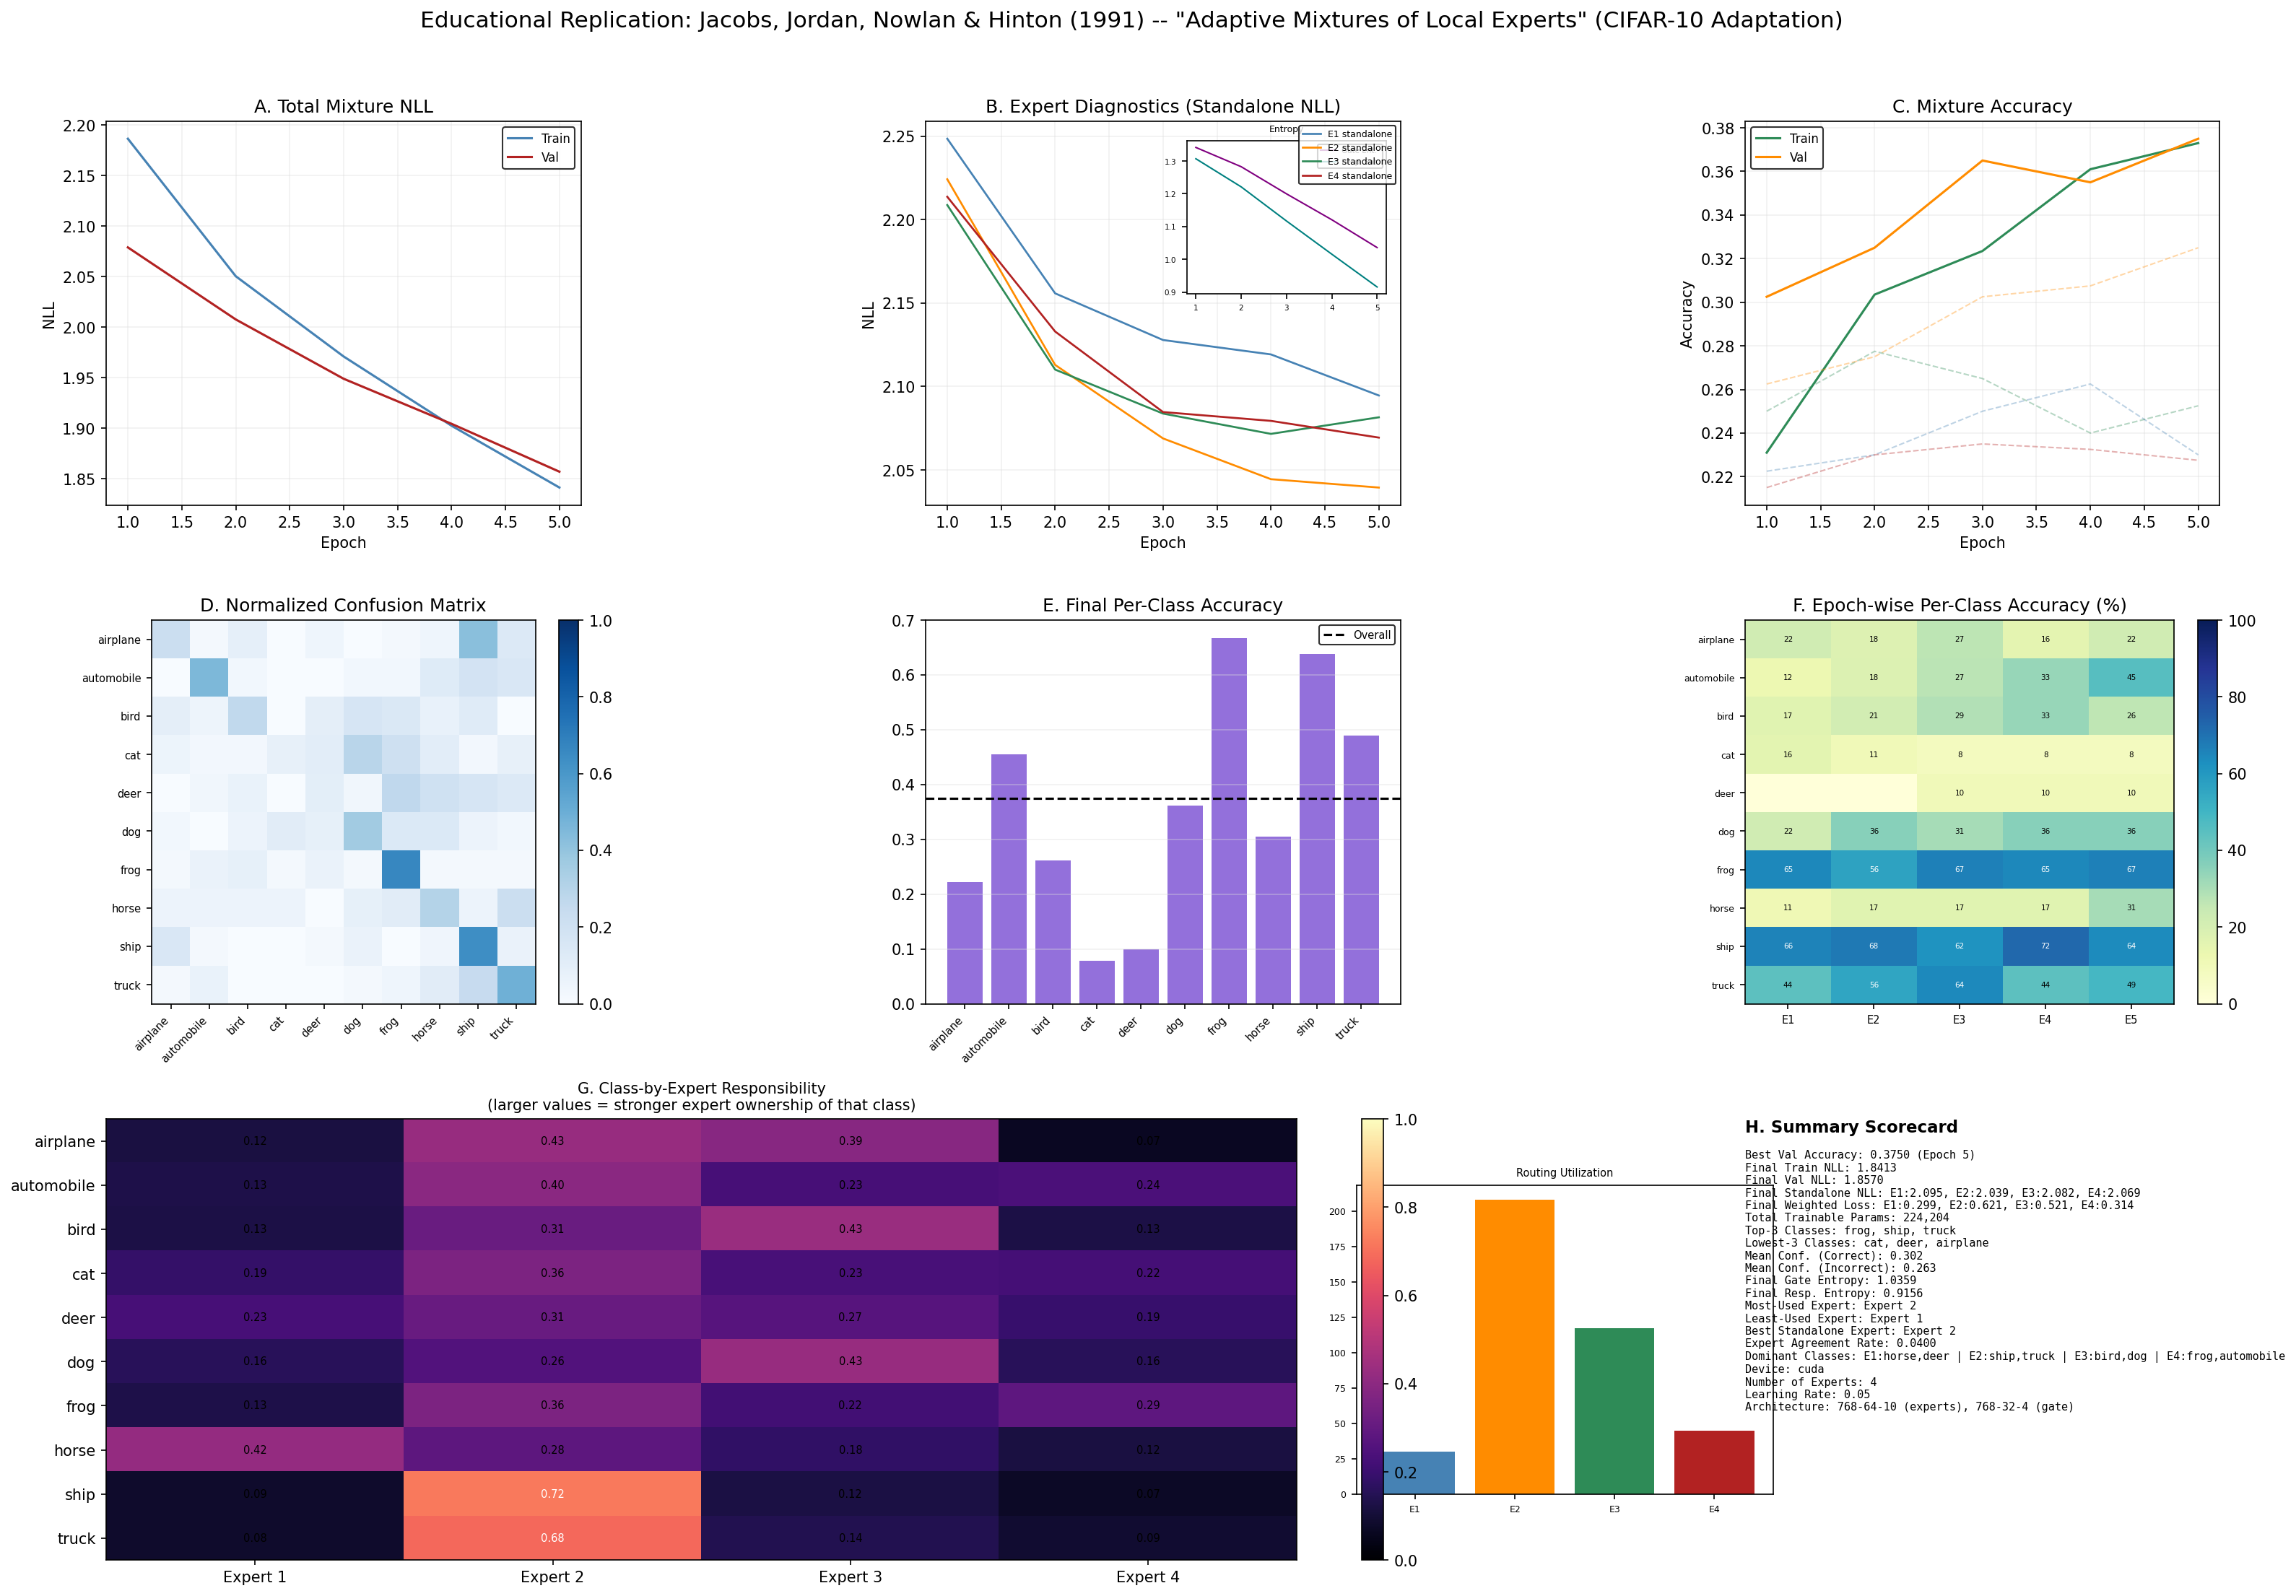

In [24]:
# ------------------------------------------------------------
# FINAL DASHBOARD (Panels A-H)
# ------------------------------------------------------------
apply_white_theme()

fig = plt.figure(figsize=(21, 15), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1, 1, 1.15])

fig.suptitle(
    "Educational Replication: Jacobs, Jordan, Nowlan & Hinton (1991) -- "
    "\"Adaptive Mixtures of Local Experts\" (CIFAR-10 Adaptation)",
    fontsize=15, color="black"
)

# Panel A: Total Mixture Loss
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs_range, history["train_loss"], label="Train", color="steelblue")
axA.plot(epochs_range, history["val_loss"], label="Val", color="firebrick")
axA.set_title("A. Total Mixture NLL")
axA.set_xlabel("Epoch"); axA.set_ylabel("NLL")
axA.legend(fontsize=8); axA.grid(True, alpha=0.4)

# Panel B: Paper-Specific Expert Diagnostics
axB = fig.add_subplot(gs[0, 1])
for e in range(NUM_EXPERTS):
    axB.plot(epochs_range, standalone_nll_matrix[:, e], label=f"E{e+1} standalone", color=expert_colors[e], lw=1.3)
axB.set_title("B. Expert Diagnostics (Standalone NLL)")
axB.set_xlabel("Epoch"); axB.set_ylabel("NLL")
axB.legend(fontsize=6, loc="upper right"); axB.grid(True, alpha=0.4)
axB_inset = axB.inset_axes([0.55, 0.55, 0.42, 0.4])
axB_inset.plot(epochs_range, history["gate_entropy"], color="purple", lw=1, label="Gate Ent.")
axB_inset.plot(epochs_range, history["responsibility_entropy"], color="teal", lw=1, label="Resp. Ent.")
axB_inset.set_title("Entropy", fontsize=6)
axB_inset.tick_params(labelsize=5)
axB_inset.legend(fontsize=5)

# Panel C: Mixture Accuracy
axC = fig.add_subplot(gs[0, 2])
axC.plot(epochs_range, history["train_acc"], label="Train", color="seagreen")
axC.plot(epochs_range, history["val_acc"], label="Val", color="darkorange")
for e in range(NUM_EXPERTS):
    axC.plot(epochs_range, [history["expert_standalone_acc"][ep][e] for ep in range(EPOCHS)],
             color=expert_colors[e], alpha=0.35, lw=1, linestyle="--")
axC.set_title("C. Mixture Accuracy")
axC.set_xlabel("Epoch"); axC.set_ylabel("Accuracy")
axC.legend(fontsize=8); axC.grid(True, alpha=0.4)

# Panel D: Normalized Confusion Matrix
axD = fig.add_subplot(gs[1, 0])
imD = axD.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
axD.set_xticks(range(NUM_CLASSES)); axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
axD.set_yticklabels(class_names, fontsize=7)
axD.set_title("D. Normalized Confusion Matrix")
fig.colorbar(imD, ax=axD, fraction=0.046)

# Panel E: Final Per-Class Accuracy
axE = fig.add_subplot(gs[1, 1])
class_positions = np.arange(NUM_CLASSES)
axE.bar(class_positions, final_val["per_class_acc"], color="mediumpurple")
axE.axhline(final_val["acc"], color="black", linestyle="--", label="Overall")
axE.set_xticks(class_positions)
axE.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
axE.set_title("E. Final Per-Class Accuracy")
axE.legend(fontsize=7); axE.grid(True, axis="y", alpha=0.4)

# Panel F: Epoch-Wise Per-Class Accuracy
axF = fig.add_subplot(gs[1, 2])
per_class_acc_matrix = np.stack(history["per_class_val_acc"], axis=0)  # [epochs, classes]
imF = axF.imshow(per_class_acc_matrix.T * 100, cmap="YlGnBu", aspect="auto", vmin=0, vmax=100)
axF.set_yticks(range(NUM_CLASSES)); axF.set_yticklabels(class_names, fontsize=6)
axF.set_xticks(range(EPOCHS)); axF.set_xticklabels([f"E{e}" for e in epochs_range], fontsize=7)
axF.set_title("F. Epoch-wise Per-Class Accuracy (%)")
for ci in range(NUM_CLASSES):
    for ei in range(EPOCHS):
        val = per_class_acc_matrix.T[ci, ei] * 100
        if val > 1:
            axF.text(ei, ci, f"{val:.0f}", ha="center", va="center", fontsize=5,
                     color="white" if val > 50 else "black")
fig.colorbar(imF, ax=axF, fraction=0.046)

# Panel G: Expert Specialization (large panel)
axG = fig.add_subplot(gs[2, 0:2])
imG = axG.imshow(class_expert_resp_matrix, cmap="magma", vmin=0, vmax=1, aspect="auto")
axG.set_xticks(range(NUM_EXPERTS)); axG.set_xticklabels([f"Expert {e+1}" for e in range(NUM_EXPERTS)])
axG.set_yticks(range(NUM_CLASSES)); axG.set_yticklabels(class_names)
axG.set_title("G. Class-by-Expert Responsibility\n"
              "(larger values = stronger expert ownership of that class)", fontsize=10)
for ci in range(NUM_CLASSES):
    for ei in range(NUM_EXPERTS):
        val = class_expert_resp_matrix[ci, ei]
        axG.text(ei, ci, f"{val:.2f}", ha="center", va="center", fontsize=7,
                  color="white" if val > 0.5 else "black")
fig.colorbar(imG, ax=axG, fraction=0.03)

axG_inset = axG.inset_axes([1.05, 0.15, 0.35, 0.7])
# FIX: plot bars at numeric positions, then attach string labels via
# set_xticklabels instead of passing strings directly as bar x-data.
# Passing raw strings to bar() on an inset axes can trigger a
# matplotlib categorical-units ConversionError when the parent axes
# already holds numeric tick/unit state (as axG does from imshow).
expert_positions = np.arange(NUM_EXPERTS)
axG_inset.bar(expert_positions, routing_counts, color=expert_colors)
axG_inset.set_xticks(expert_positions)
axG_inset.set_xticklabels([f"E{e+1}" for e in range(NUM_EXPERTS)], fontsize=6)
axG_inset.set_title("Routing Utilization", fontsize=7)
axG_inset.tick_params(labelsize=6)

# Panel H: Summary Scorecard
axH = fig.add_subplot(gs[2, 2])
axH.axis("off")

best_epoch_idx = int(np.argmax(history["val_acc"]))
best_val_acc = history["val_acc"][best_epoch_idx]
best_epoch = best_epoch_idx + 1

top3_idx = np.argsort(final_val["per_class_acc"])[::-1][:3]
bottom3_idx = np.argsort(final_val["per_class_acc"])[:3]
top3_names = ", ".join(class_names[i] for i in top3_idx)
bottom3_names = ", ".join(class_names[i] for i in bottom3_idx)

most_used_expert = int(np.argmax(routing_counts)) + 1
least_used_expert = int(np.argmin(routing_counts)) + 1
best_standalone_expert = int(np.argmax(expert_standalone_acc_final)) + 1

dominant_classes_str = " | ".join(
    f"E{e+1}:{','.join(expert_top_classes[e][:2])}" for e in range(NUM_EXPERTS)
)

standalone_nll_final_str = ", ".join(f"E{e+1}:{standalone_nll_matrix[-1, e]:.3f}" for e in range(NUM_EXPERTS))
weighted_loss_final_str = ", ".join(f"E{e+1}:{weighted_loss_matrix[-1, e]:.3f}" for e in range(NUM_EXPERTS))

scorecard_lines = [
    f"Best Val Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})",
    f"Final Train NLL: {history['train_loss'][-1]:.4f}",
    f"Final Val NLL: {history['val_loss'][-1]:.4f}",
    f"Final Standalone NLL: {standalone_nll_final_str}",
    f"Final Weighted Loss: {weighted_loss_final_str}",
    f"Total Trainable Params: {total_params:,}",
    f"Top-3 Classes: {top3_names}",
    f"Lowest-3 Classes: {bottom3_names}",
    f"Mean Conf. (Correct): {mean_conf_correct:.3f}" if not np.isnan(mean_conf_correct) else "Mean Conf. (Correct): N/A",
    f"Mean Conf. (Incorrect): {mean_conf_incorrect:.3f}" if not np.isnan(mean_conf_incorrect) else "Mean Conf. (Incorrect): N/A",
    f"Final Gate Entropy: {history['gate_entropy'][-1]:.4f}",
    f"Final Resp. Entropy: {history['responsibility_entropy'][-1]:.4f}",
    f"Most-Used Expert: Expert {most_used_expert}",
    f"Least-Used Expert: Expert {least_used_expert}",
    f"Best Standalone Expert: Expert {best_standalone_expert}",
    f"Expert Agreement Rate: {final_agreement_rate:.4f}",
    f"Dominant Classes: {dominant_classes_str}",
    f"Device: {device.type}",
    f"Number of Experts: {NUM_EXPERTS}",
    f"Learning Rate: {LEARNING_RATE}",
    f"Architecture: 768-64-10 (experts), 768-32-4 (gate)",
]

axH.text(0.0, 1.0, "H. Summary Scorecard", fontsize=11, weight="bold",
         color="black", va="top", transform=axH.transAxes)
axH.text(0.0, 0.93, "\n".join(scorecard_lines), fontsize=7.3, color="black",
         va="top", transform=axH.transAxes, family="monospace")

fig.tight_layout(rect=[0, 0, 1, 0.96])

buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Experimental Results: CIFAR-10 Replication of Adaptive Mixtures of Local Experts

## Panel A — Total Mixture Negative Log-Likelihood (Training vs. Validation)

### Overview
This panel tracks the mixture negative log-likelihood (NLL) objective — the paper's core training criterion — across five epochs, comparing training and validation loss to assess convergence of the joint expert-gate optimization.

### Key Findings
Both curves decrease smoothly and nearly monotonically from ~2.19/2.08 (train/val) at epoch 1 to ~1.84/1.86 at epoch 5, with the two curves crossing around epoch 3.5–4 (validation initially lower, then training overtakes it).

### Discussion
The steady decline confirms that gradient descent on the mixture NLL is correctly optimizing the joint expert-gate system, consistent with the paper's formulation of the objective as the negative log-likelihood of a Gaussian-mixture-style generative model. The crossover, with training loss ultimately dropping below validation loss, is the expected signature of a model beginning to fit the specific training sample more closely than the held-out set — a mild but unsurprising indication of limited generalization capacity given only 2,000 training examples. Overall, the smooth joint decrease supports the paper's central claim that expert and gating parameters can be trained together via standard gradient descent on a single differentiable mixture objective.

### Limitations
The gap between training and validation loss remains small throughout, so no strong overfitting conclusion can be drawn from five epochs alone; longer training would be needed to determine whether this trend continues or plateaus.

---

## Panel B — Expert Diagnostics (Standalone NLL and Entropy)

### Overview
This panel isolates each expert's own (unweighted) predictive NLL, alongside an inset tracking gating entropy and responsibility entropy — instrumenting the paper's central mechanism of competitive specialization.

### Key Findings
All four experts' standalone NLL curves decrease together from ~2.20–2.25 to ~2.04–2.10, with Expert 1 consistently trailing the other three (which cluster closely together) by epoch 5. The inset shows both gating entropy and responsibility entropy decreasing steadily from ~1.3 to ~0.9–1.0 nats.

### Discussion
The declining entropy curves are a meaningful and theoretically expected signature of the paper's competitive mechanism: as training progresses, the gate becomes less uniform in its expert selection (lower gating entropy) and the posterior responsibility distribution becomes more peaked (lower responsibility entropy), both indicating that specific experts are increasingly "winning" specific inputs rather than sharing responsibility diffusely. This is consistent with Jacobs et al.'s description of how symmetry breaks once experts begin receiving disproportionate error from different subsets of cases. However, the fact that all four experts' standalone losses decrease in tandem (rather than diverging sharply, with only one expert improving on a given input region) suggests the specialization signal here is more moderate than the essentially binary decision lines reported in the original paper's vowel task.

### Limitations
With only 4 discrete "nats" of maximum possible entropy for 4 experts (ln 4 ≈ 1.39), the observed decrease from ~1.3 to ~0.95 is a partial rather than complete reduction, indicating routing remains only moderately decisive after 5 epochs — this is expected given the short training horizon and should not be over-interpreted as full convergence to specialization.

---

## Panel C — Mixture Accuracy (Train vs. Validation, with Faint Expert Standalone Curves)

### Overview
Tracks mixture top-1 classification accuracy across epochs, with each individual expert's standalone accuracy overlaid as a faint reference, evaluating overall task performance and the incremental contribution of the mixture relative to any single expert.

### Key Findings
Both training and validation mixture accuracy increase from ~0.22–0.30 to ~0.37, converging closely by epoch 5. The faint dashed expert-standalone accuracy curves remain visibly lower and more volatile throughout, generally in the 0.21–0.33 range with no single expert closely tracking the mixture curve.

### Discussion
The mixture consistently outperforming any individual expert's standalone accuracy is a direct, positive confirmation of the paper's central hypothesis: routing decisions and responsibility-weighted learning yield a combined system whose predictive accuracy exceeds what any single "generalist" expert achieves alone. This validates the practical utility of the gating mechanism beyond a simple diagnostic role. The relatively close tracking of train and validation accuracy (unlike the loss curves, which showed a small crossover) suggests the accuracy metric is less sensitive to the mild overfitting seen in Panel A, likely because argmax decisions are more robust to small shifts in absolute probability magnitudes.

### Limitations
Final accuracy (~37.5%) remains well below what a convolutional architecture would achieve on CIFAR-10, which is expected given the intentionally simple, non-convolutional, small-hidden-layer expert/gate architecture; this panel demonstrates relative (mixture vs. expert) improvement rather than absolute state-of-the-art performance.

---

## Panel D — Normalized Confusion Matrix

### Overview
Displays row-normalized mixture prediction distributions across all ten CIFAR-10 classes, revealing systematic classification biases and confusions in the final trained system.

### Key Findings
Strong diagonal mass is visible for "automobile," "dog," "frog," "horse," and "ship," while "cat," "deer," and "airplane" show weak diagonal values and are frequently misclassified — notably, "cat" and "deer" both show substantial off-diagonal mass toward "dog" and "frog," and "airplane" is frequently confused with "ship."

### Discussion
This pattern is more balanced than a full class-collapse failure mode (multiple classes show correct-class dominance, unlike a scenario where predictions concentrate in only 2–3 columns), indicating that the mixture-of-experts architecture achieves broader class coverage than a single collapsed classifier might. The visual/semantic confusions that do appear (cat/dog, deer/other quadrupeds, airplane/ship) are intuitive given shared low-level visual features (color, background, silhouette) that a shallow, non-convolutional pooled-pixel representation cannot fully disambiguate.

### Limitations
The relatively weak diagonal for "cat," "deer," and "airplane" indicates the mixture has not achieved uniformly strong per-class discrimination, and the confusion matrix alone cannot determine whether this stems from routing failures (wrong expert selected) versus genuine representational limitations shared across all experts.

---

## Panel E — Final Per-Class Accuracy

### Overview
Reports final validation accuracy stratified by class against the overall accuracy baseline, complementing the confusion matrix with a direct per-class performance view.

### Key Findings
"Frog" (~0.67) and "ship" (~0.64) achieve the highest per-class accuracy, followed by "automobile" (~0.46) and "truck" (~0.49); "cat" (~0.08) and "deer" (~0.10) perform far below the overall average (~0.375), with "airplane" (~0.22) also below average.

### Discussion
This per-class disparity is consistent with, and helps quantify, the confusion matrix pattern in Panel D: the mixture system has developed strong, usable representations for a subset of visually distinctive classes (frog, ship) while struggling substantially with visually ambiguous or fine-grained categories (cat, deer). This is a common pattern in shallow, non-convolutional architectures where texture/color statistics after aggressive pooling favor classes with more uniform, distinctive coloration (e.g., ship's blue-water context, frog's green coloration) over classes requiring fine shape discrimination (cat vs. dog vs. deer silhouettes).

### Limitations
The extremely low accuracy for "cat" and "deer" (near or below chance for a 10-class problem) suggests these classes may be effectively unlearned by the entire mixture rather than selectively difficult — additional analysis of expert-level per-class responsibility (Panel G) is needed to distinguish "no expert learned this class" from "experts disagree and cancel out."

---

## Panel F — Epoch-wise Per-Class Accuracy Heatmap

### Overview
Visualizes the evolution of per-class validation accuracy across all five training epochs, examining whether class-specific performance is stable, improving, or fluctuating during training.

### Key Findings
"Frog" and "ship" show consistently high accuracy from epoch 1 onward (58–72%), while "cat" remains flat and low (8% across nearly all epochs) and "deer" only becomes classifiable starting at epoch 3 (10% at epochs 3–5, 0% before). "Automobile" and "horse" show a clear upward trend (12%→45% and 11%→31%, respectively) across epochs.

### Discussion
The stable, near-immediate strong performance on "frog" and "ship" suggests these classes have highly separable low-level features that are easy for shallow pooled-input networks to capture almost immediately, requiring little iterative refinement. In contrast, the persistently near-zero accuracy for "cat" throughout training indicates a genuine representational bottleneck rather than a transient training dynamic — five epochs of gradient descent were insufficient (or architecturally insufficient) to carve out a usable region of input space for this class. The improving trends for "automobile" and "horse" demonstrate that some classes do benefit from continued training within the studied horizon, suggesting the model has not yet converged and additional epochs might yield further gains for these categories specifically.

### Limitations
Given the short (5-epoch) training window and small subset size (2,000 images), it is not possible to determine whether "cat" would eventually be learned with more epochs or whether this reflects a structural limitation of the architecture (e.g., pooling destroying fine-grained shape cues necessary for cat/dog/deer discrimination).

---

## Panel G — Class-by-Expert Responsibility Matrix

### Overview
This is the paper's central diagnostic: mean posterior responsibility for each (class, expert) pair, directly testing whether the gating mechanism has induced meaningful task decomposition among experts, as claimed in the original 1991 study's vowel discrimination results.

### Key Findings
Expert 2 dominates responsibility for "ship" (0.72) and "truck" (0.68), and shares substantial responsibility for "airplane" (0.43) and "automobile" (0.40). Expert 3 shows moderate-to-strong responsibility for "bird" (0.43), "dog" (0.43), and "airplane" (0.39). Expert 1 shows a notable peak only for "horse" (0.42) but otherwise low values across most classes. Expert 4 shows no strong peak for any class, with values generally below 0.30.

### Discussion
This matrix provides genuine, class-differentiated evidence of specialization consistent with the paper's central thesis: rather than uniform responsibility across all experts for all classes (which would indicate no specialization), distinct experts show clearly elevated responsibility for distinct class subsets (Expert 2: ship/truck/vehicles; Expert 3: bird/dog; Expert 1: horse). This mirrors the qualitative finding in the original paper's Figure 3, where different experts' decision lines diverged to specialize on different class pairs as training progressed. However, the specialization here is partial rather than exclusive — several classes (e.g., airplane, automobile) show substantial responsibility split between two experts (2 and 3) rather than concentrating in one, and Expert 4 appears to have failed to develop a clear specialty, consistent with the original paper's observation that some experts in a mixture may end up with "effectively zero" mixing proportion for all cases.

### Limitations
The moderate (rather than sharply peaked, near-1.0) responsibility values for most classes indicate that specialization, while directionally present, has not fully converged to the clean single-expert-per-subtask solutions reported in the original 25-simulation vowel experiments — likely due to the short training duration, harder underlying task (10-way natural image classification vs. 4-way formant discrimination), and simpler, non-hierarchical routing decisions available to a single shallow gate.

---

## Panel H — Summary Scorecard (Including Routing Utilization Inset)

### Overview
Consolidates final quantitative metrics — accuracy, loss, entropy, expert utilization, and confidence — into a single reference panel, with an embedded routing-utilization bar chart showing how many samples each expert dominantly serves.

### Key Findings
Expert 2 is the most-used expert (assigned gate-argmax responsibility for the largest share of samples, visibly >200 in the routing bar chart) and also achieves the best standalone accuracy; Expert 1 is the least-used. Mean confidence is modestly higher for correct predictions (0.302) than incorrect ones (0.263). Final gate entropy (1.036) remains above final responsibility entropy (0.916), and the expert agreement rate is very low (0.04).

### Discussion
The routing utilization imbalance (Expert 2 dominating, Expert 1 underused) combined with Expert 2 also having the best standalone accuracy suggests the gate has learned to trust its most generally capable expert disproportionately, rather than distributing load evenly — a documented tendency in mixture-of-experts systems absent explicit load-balancing incentives, and consistent with the original paper's own observation that, empirically, only 2–3 of 4 or 8 experts typically end up with non-negligible mixing proportions. The extremely low expert agreement rate (4%) indicates that the four experts, despite converging on a shared overall loss, have learned substantially different individual decision functions — direct evidence that the architecture has NOT collapsed into four redundant copies of the same classifier, which is an important sanity check supporting genuine functional diversity among experts (a necessary, though not sufficient, condition for the specialization claimed in Panel G). The modest gap between correct and incorrect prediction confidence indicates weak but present calibration, better than a near-tie but still far from a well-calibrated classifier.

### Limitations
This is a single-seed, five-epoch, 2,000-sample educational demonstration; the near-total lack of expert agreement, while suggestive of functional diversity, could equally reflect noisy, undertrained individual experts producing near-random disagreement rather than principled specialization — Panel G's structured class-by-expert responsibility pattern is necessary to help disambiguate genuine specialization from mere noise, but longer training and multiple seeds would be needed to confirm the stability of this finding.

---

## Overall Synthesis

Collectively, these results provide meaningful, if partial, empirical support for the paper's central claims about competitive specialization in mixtures of local experts. The joint mixture NLL decreases smoothly (Panel A), gating and responsibility entropy decline over training (Panel B), and — most importantly — the class-by-expert responsibility matrix (Panel G) shows genuinely differentiated, non-uniform expert specialization patterns (Expert 2 on vehicles/ship, Expert 3 on animals, Expert 1 on horse) alongside a very low inter-expert agreement rate (Panel H), together indicating that the four experts have developed functionally distinct, non-redundant representations rather than collapsing into a homogeneous ensemble. The mixture also reliably outperforms any single expert's standalone accuracy (Panel C), validating the practical benefit of the gating mechanism. However, specialization remains incomplete relative to the crisp task decomposition reported in the original 1991 vowel discrimination experiments: several classes split responsibility across two experts rather than one, one expert (Expert 4) fails to develop a clear specialty, and overall classification accuracy remains modest — all plausibly attributable to the short five-epoch training budget, small 2,000-image training subset, and the substantially harder 10-way natural-image task compared to the original paper's 4-class formant discrimination benchmark.

# Related Work Cited in the Paper

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Barto, A. G. | 1985 | Learning by statistical cooperation of self-interested neuron-like computing elements | *Human Neurobiology*, 4, 229–256 | Provided the model of generalized learning automata that the authors draw on as a precedent for making competitive learning input-conditional (associative), by analogy to how Barto added an input vector and made automaton actions conditional on it. |
| Hampshire, J., & Waibel, A. | 1989 | The meta-pi network: Building distributed knowledge representations for robust pattern recognition | Tech. Rep. CMU-CS-89-166, Carnegie Mellon University, Pittsburgh, PA | Described an earlier expert-plus-gating-network system usable when the task decomposition is known in advance (experts trained separately on preassigned subtasks); cited as prior work using a linear-combination error function that does not encourage localization, motivating this paper's redefined competitive error function. |
| Jacobs, R. A., & Jordan, M. I. | 1991 | Learning piecewise control strategies in a modular connectionist architecture | In preparation | Cited as related, forthcoming work extending the modular expert/gating architecture to control strategy learning, situating the current paper within a broader research program on modular connectionist systems. |
| Jacobs, R. A., Jordan, M. I., & Barto, A. G. | 1991 | Task decomposition through competition in a modular connectionist architecture: The what and where vision tasks | *Cognitive Science*, in press | Companion/related work applying the competition-based modular architecture to vision tasks (object identity and location), illustrating the broader applicability of the task-decomposition-through-competition principle introduced in this paper. |
| Jacobs, R. A., Jordan, M. I., Nowlan, S. J., & Hinton, G. E. (implicitly, via Jacobs et al. 1990 reference) | 1990 | (Related system that learns to allocate cases to experts; full citation not detailed in excerpted references) | Not specified in text | Described a system that *learns* (rather than assumes) how to allocate training cases to experts; cited as the immediate predecessor system whose linear-combination error function is critiqued and improved upon via the stochastic/competitive error function proposed in this paper. |
| McLachlan, G. J., & Basford, K. E. | 1988 | Mixture Models: Inference and Applications to Clustering | Marcel Dekker, New York | Source of the statistical terminology ("mixing proportions") and mixture-model framework underlying the paper's probabilistic (Gaussian mixture) interpretation of the negative log-probability error function. |
| Moody, J., & Darken, C. | 1989 | Fast learning in networks of locally-tuned processing units | *Neural Computation*, 1(2), 281–294 | Cited as an example of models that use competitive learning as a preprocessing stage within an associative network, representing the conventional view of competitive learning's role that this paper contrasts with its own reinterpretation (data vectors as outputs rather than inputs). |
| Nowlan, S. J. | 1990a | Maximum likelihood competitive learning | In *Advances in Neural Information Processing Systems 2*, D. S. Touretzky (ed.), pp. 574–582, Morgan Kaufmann, San Mateo, CA | Provides the maximum-likelihood formulation of "soft" competitive learning that this paper builds on and generalizes into the input-conditional mixture-of-experts framework. |
| Nowlan, S. J. | 1990b | Competing experts: An experimental investigation of associative mixture models | Tech. Rep. CRG-TR-90-5, University of Toronto, Toronto, Canada | Source of the vowel discrimination dataset and experimental setup used to evaluate the mixture-of-experts model in Section 3 of this paper. |
| Peterson, G. E., & Barney, H. L. | 1952 | Control methods used in a study of the vowels | *Journal of the Acoustical Society of America*, 24, 175–184 | Original source of the vowel formant dataset (hVd context, first/second formants for vowels [i], [I], [a], [Λ]) used as the empirical benchmark for the vowel discrimination experiments in this paper. |